# Behavioral FX estimation 

Config

In [2]:
import pandas as pd
from dbnomics import fetch_series
import numpy as np
import os
from dataclasses import dataclass
from typing import Dict, Tuple, List
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.special import expit  # logistic numerically stable
from scipy import stats
import matplotlib.pyplot as plt
import os

import matplotlib.pyplot as plt

# Set paths for saving outputs
plot_path = "/Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Results/Plots"
results_path = "/Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Results/Results"

# Create directories if they don't exist
os.makedirs(plot_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

# Set plot style
plt.style.use('seaborn-v0_8-paper')

In [ ]:
import pandas as pd
from dbnomics import fetch_series

# ------------------------------
# 1) Config
# ------------------------------
# Countries using monetary policy rate (FPOLM_PA)
mp_countries = {
    "AU": "Australia",
    "ID": "Indonesia",
    "TR": "Türkiye"
}

# Countries using money market rate (FIMM_PA)
mm_countries = {
    "BR": "Brazil",
    "KR": "Korea",
    # "MY": "Malaysia", 
    "MX": "Mexico",
    "NZ": "New Zealand",
    "PH": "Philippines",
    "TH": "Thailand"
}

# Countries using standard series (exchange rate and CPI only, rates handled separately)
other_countries = {
    "JP": "Japan", 
    "GB": "United Kingdom", 
    "CH": "Switzerland", 
    "CA": "Canada",
    "U2": "Euro Area"
}

# Combine all countries for exchange rate and CPI fetching
all_countries = {**mp_countries, **mm_countries, **other_countries}

# ------------------------------
# 2) Fetch monthly IFS series
# ------------------------------
dfs = []

# Fetch exchange rate and CPI for all countries
for iso2, country in all_countries.items():
    for var, code in [("exchange_rate", "ENDE_XDC_USD_RATE"), ("cpi", "PCPI_IX")]:
        sid = f"IMF/IFS/M.{iso2}.{code}"
        try:
            df = fetch_series(sid)
            df["country"]    = country
            df["variable"]   = var
            df["series_id"]  = sid
            df["source"]     = "IMF/IFS"
            df["freq"]       = "M"
            df["interpolated"] = False
            dfs.append(df)
        except Exception:
            continue

# Fetch monetary policy rate for MP countries
for iso2, country in mp_countries.items():
    sid = f"IMF/IFS/M.{iso2}.FPOLM_PA"
    try:
        df = fetch_series(sid)
        df["country"]    = country
        df["variable"]   = "policy_rate"
        df["series_id"]  = sid
        df["source"]     = "IMF/IFS"
        df["freq"]       = "M"
        df["interpolated"] = False
        dfs.append(df)
    except Exception:
        continue

# Fetch money market rate for MM countries
for iso2, country in mm_countries.items():
    sid = f"IMF/IFS/M.{iso2}.FIMM_PA"
    try:
        df = fetch_series(sid)
        df["country"]    = country
        df["variable"]   = "policy_rate"
        df["series_id"]  = sid
        df["source"]     = "IMF/IFS"
        df["freq"]       = "M"
        df["interpolated"] = False
        dfs.append(df)
        print(f"Fetched MM rate for {country}: {sid}")
    except Exception as e:
        print(f"Error fetching MM rate for {country} {sid}: {e}")

# ------------------------------
# 2b) Fetch US series (CPI and policy rate only, no exchange rate)
# ------------------------------
us_series = {
    "cpi": "PCPI_IX",
    "policy_rate": "FPOLM_PA"
}

for var, code in us_series.items():
    sid = f"IMF/IFS/M.US.{code}"
    try:
        df = fetch_series(sid)
        df["country"]    = "United States"
        df["variable"]   = var
        df["series_id"]  = sid
        df["source"]     = "IMF/IFS"
        df["freq"]       = "M"
        df["interpolated"] = False
        dfs.append(df)
        print(f"Fetched US: {sid}")
    except Exception as e:
        print(f"Error fetching US {sid}: {e}")

# Special CPI series for Euro Area
sid = "IMF/IFS/M.U2.PCPIHA_IX"
try:
    df = fetch_series(sid)
    df["country"]    = "Euro Area"
    df["variable"]   = "cpi"
    df["series_id"]  = sid
    df["source"]     = "IMF/IFS"
    df["freq"]       = "M"
    df["interpolated"] = False
    dfs.append(df)
    print(f"Fetched Euro Area CPI: {sid}")
except Exception as e:
    print(f"Error fetching Euro Area CPI {sid}: {e}")

# Combine all dataframes
df_all = pd.concat(dfs, ignore_index=True)

# Normalize date to month-end
df_all["date"] = pd.to_datetime(df_all["period"]).dt.to_period("M").dt.to_timestamp("M")

# --- Indonesia: fill FPOLM_PA gaps with FIMM_PA ---

sid_alt = "IMF/IFS/M.ID.FIMM_PA"
alt = fetch_series(sid_alt)
alt["country"]      = "Indonesia"
alt["variable"]     = "policy_rate_alt"
alt["series_id"]    = sid_alt
alt["source"]       = "IMF/IFS"
alt["freq"]         = "M"
alt["interpolated"] = False
alt["date"] = pd.to_datetime(alt["period"]).dt.to_period("M").dt.to_timestamp("M")

prim = (df_all[(df_all.country=="Indonesia") & (df_all.variable=="policy_rate")]
              [["date","value"]]
              .rename(columns={"value":"value_prim"}))

alt2 = alt[["date","value"]].rename(columns={"value":"value_alt"})
merged = prim.merge(alt2, on="date", how="outer").sort_values("date")
filled = merged.assign(value=merged["value_prim"].combine_first(merged["value_alt"]))[["date","value"]]

id_rows = (df_all[(df_all.country=="Indonesia") & (df_all.variable=="policy_rate")]
           .drop(columns=["value"])
           .merge(filled, on="date", how="right"))

id_rows["country"]      = "Indonesia"
id_rows["variable"]     = "policy_rate"
id_rows["source"]       = "IMF/IFS (FPOLM_PA filled w/ FIMM_PA)"
id_rows["series_id"]    = "FPOLM_PA+FIMM_PA"
id_rows["freq"]         = "M"
id_rows["interpolated"] = False

mask_old = (df_all.country=="Indonesia") & (df_all.variable=="policy_rate")
df_all = pd.concat([df_all.loc[~mask_old], id_rows], ignore_index=True)

print("Indonesia policy_rate NA after fill:",
      df_all[(df_all.country=="Indonesia") & (df_all.variable=="policy_rate")]["value"].isna().sum())

# ------------------------------
# 3) Interpolate AU/NZ quarterly CPI to monthly and append
# ------------------------------
filters = [{"code": "interpolate", "parameters": {"frequency": "monthly", "method": "spline"}}]
df_cpi_qm = fetch_series([
    "IMF/IFS/Q.AU.PCPI_IX",
    "IMF/IFS/Q.NZ.PCPI_IX",
], filters=filters)

cc_map = {"AU": "Australia", "NZ": "New Zealand"}
df_cpi_qm["country"]   = df_cpi_qm["series_code"].str.split(".").str[1].map(cc_map)
df_cpi_qm["variable"]  = "cpi"
df_cpi_qm["series_id"] = df_cpi_qm[["provider_code","dataset_code","series_code"]].agg("/".join, axis=1) + ":interp_M"
df_cpi_qm["source"]    = df_cpi_qm["provider_code"] + "/" + df_cpi_qm["dataset_code"]
df_cpi_qm["freq"]      = "M"
df_cpi_qm["interpolated"] = True
df_cpi_qm["date"] = pd.to_datetime(df_cpi_qm["period"]).dt.to_period("M").dt.to_timestamp("M")

# Drop any existing AU/NZ monthly CPI (if present) to avoid duplicates, then append
mask = (df_all["country"].isin(["Australia","New Zealand"])) & (df_all["variable"]=="cpi")
df_all = pd.concat([df_all.loc[~mask], df_cpi_qm], ignore_index=True)

# ------------------------------
# 3b) Replace policy_rate with OECD interbank rate for selected countries
# ------------------------------
oecd_series = {
    "Canada":          "OECD/DSD_KEI@DF_KEI/CAN.M.IRSTCI.PA._Z._Z._Z",
    "Switzerland":     "OECD/DSD_KEI@DF_KEI/CHE.M.IRSTCI.PA._Z._Z._Z",
    "Euro Area":       "OECD/DSD_KEI@DF_KEI/EA19.M.IRSTCI.PA._Z._Z._Z",
    "United Kingdom":  "OECD/DSD_KEI@DF_KEI/GBR.M.IRSTCI.PA._Z._Z._Z",
    "Japan":           "OECD/DSD_KEI@DF_KEI/JPN.M.IRSTCI.PA._Z._Z._Z",
}

dfs_oecd = []
for country, sid in oecd_series.items():
    try:
        dfo = fetch_series(sid)
        dfo["country"]       = country
        dfo["variable"]      = "policy_rate"  # keep same variable name, now sourced from OECD
        dfo["series_id"]     = dfo[["provider_code","dataset_code","series_code"]].agg("/".join, axis=1)
        dfo["source"]        = dfo["provider_code"] + "/" + dfo["dataset_code"]
        dfo["freq"]          = "M"
        dfo["interpolated"]  = False
        dfo["date"] = pd.to_datetime(dfo["period"]).dt.to_period("M").dt.to_timestamp("M")
        dfs_oecd.append(dfo)
        print(f"Fetched OECD rate: {sid}")
    except Exception as e:
        print(f"Error fetching OECD series {sid}: {e}")

if dfs_oecd:
    df_oecd = pd.concat(dfs_oecd, ignore_index=True)

    # Drop existing IMF policy_rate for these countries and replace with OECD
    replace_countries = list(oecd_series.keys())
    mask_replace = (df_all["country"].isin(replace_countries)) & (df_all["variable"] == "policy_rate")
    df_all = pd.concat(
        [
            df_all.loc[~mask_replace],
            df_oecd[["country","date","variable","value","source","freq","series_id","interpolated"]],
        ],
        ignore_index=True
    )

# ------------------------------
# 4) Final tidy-long dataset
# ------------------------------
cols = ["country","date","variable","value","source","freq","series_id","interpolated"]
df_all = df_all[cols].sort_values(["country","variable","date"]).reset_index(drop=True)

df_sample = df_all


# Pivot to wide format for easier calculation
df_wide = df_sample.pivot_table(
    index=['country', 'date'],
    columns='variable',
    values='value'
).reset_index()

# Missing one observation from Philippines interest rates (2022-01-31). Interpolating by computing mean between adjacent months.
date0 = pd.Timestamp('2022-01-31')
affected = df_wide.loc[(df_wide['date'] == date0) & df_wide['policy_rate'].isna(), ['country','date']]
# Compute mean between adjacent months
for country in affected['country']:
    mask = (df_wide['country'] == country) & (df_wide['date'].between(date0 - pd.DateOffset(months=1), date0 + pd.DateOffset(months=1)))
    df_wide.loc[mask, 'policy_rate'] = df_wide.loc[mask, 'policy_rate'].fillna(df_wide.loc[mask, 'policy_rate'].mean())

Could not load series: {'dataset_code': 'IFS', 'message': 'Could not load series', 'provider_code': 'IMF', 'series_code': 'M.AU.PCPI_IX'}
Could not load series: {'dataset_code': 'IFS', 'message': 'Could not load series', 'provider_code': 'IMF', 'series_code': 'M.NZ.PCPI_IX'}
Could not load series: {'dataset_code': 'IFS', 'message': 'Could not load series', 'provider_code': 'IMF', 'series_code': 'M.U2.PCPI_IX'}


Fetched MM rate for Brazil: IMF/IFS/M.BR.FIMM_PA
Fetched MM rate for Korea: IMF/IFS/M.KR.FIMM_PA
Fetched MM rate for Mexico: IMF/IFS/M.MX.FIMM_PA
Fetched MM rate for New Zealand: IMF/IFS/M.NZ.FIMM_PA
Fetched MM rate for Philippines: IMF/IFS/M.PH.FIMM_PA
Fetched MM rate for Thailand: IMF/IFS/M.TH.FIMM_PA
Fetched US: IMF/IFS/M.US.PCPI_IX
Fetched US: IMF/IFS/M.US.FPOLM_PA
Fetched Euro Area CPI: IMF/IFS/M.U2.PCPIHA_IX
Indonesia policy_rate NA after fill: 0
Fetched OECD rate: OECD/DSD_KEI@DF_KEI/CAN.M.IRSTCI.PA._Z._Z._Z
Fetched OECD rate: OECD/DSD_KEI@DF_KEI/CHE.M.IRSTCI.PA._Z._Z._Z
Fetched OECD rate: OECD/DSD_KEI@DF_KEI/EA19.M.IRSTCI.PA._Z._Z._Z
Fetched OECD rate: OECD/DSD_KEI@DF_KEI/GBR.M.IRSTCI.PA._Z._Z._Z
Fetched OECD rate: OECD/DSD_KEI@DF_KEI/JPN.M.IRSTCI.PA._Z._Z._Z


In [5]:
"""
Quick analysis code to paste into your Jupyter notebook
Copy and paste this into a new cell after df_sample is created
"""

# Quick Missing Observations Analysis for df_sample
print("="*80)
print("MISSING OBSERVATIONS ANALYSIS FOR df_sample")
print("="*80)

# 1. Basic info
print(f"\nTotal rows: {len(df_sample):,}")
print(f"Date range: {df_sample['date'].min()} to {df_sample['date'].max()}")
print(f"Countries: {df_sample['country'].nunique()}")
print(f"Variables: {df_sample['variable'].nunique()}")

# 2. Missing values in 'value' column
print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
missing_count = df_sample['value'].isna().sum()
print(f"Total missing values: {missing_count:,} ({missing_count/len(df_sample)*100:.2f}%)")

if missing_count > 0:
    print("\nMissing values by country and variable:")
    print(df_sample[df_sample['value'].isna()].groupby(['country', 'variable']).size())

# 3. Check for gaps in monthly time series
print("\n" + "="*80)
print("GAPS IN MONTHLY TIME SERIES")
print("="*80)

gaps_summary = []

for (country, variable), group in df_sample.groupby(['country', 'variable']):
    group = group.sort_values('date')
    min_date = group['date'].min()
    max_date = group['date'].max()
    
    # Create complete monthly range
    complete_range = pd.date_range(start=min_date, end=max_date, freq='M')
    
    # Find missing dates
    existing_dates = set(group['date'])
    missing_dates = [d for d in complete_range if d not in existing_dates]
    
    if missing_dates:
        gaps_summary.append({
            'Country': country,
            'Variable': variable,
            'Start': min_date.strftime('%Y-%m'),
            'End': max_date.strftime('%Y-%m'),
            'Expected': len(complete_range),
            'Actual': len(group),
            'Missing': len(missing_dates),
            'First_Missing_Dates': ', '.join([d.strftime('%Y-%m') for d in missing_dates[:5]])
        })

if gaps_summary:
    gaps_df = pd.DataFrame(gaps_summary)
    print(f"\nFound {len(gaps_summary)} series with gaps:\n")
    print(gaps_df.to_string(index=False))
else:
    print("\n✓ No gaps found! All series have complete monthly observations.")

# 4. Observation count summary
print("\n" + "="*80)
print("OBSERVATION COUNT BY COUNTRY-VARIABLE")
print("="*80)

summary = df_sample.groupby(['country', 'variable']).agg({
    'date': ['min', 'max', 'count'],
    'value': lambda x: x.notna().sum()
})
summary.columns = ['Start', 'End', 'Total_Obs', 'Non_Null']
summary['Missing_Values'] = summary['Total_Obs'] - summary['Non_Null']
print(summary)

# 5. Check duplicates
print("\n" + "="*80)
print("DUPLICATE CHECK")
print("="*80)
dup_count = df_sample.duplicated(subset=['country', 'date', 'variable']).sum()
if dup_count > 0:
    print(f"⚠ Found {dup_count} duplicates!")
    dups = df_sample[df_sample.duplicated(subset=['country', 'date', 'variable'], keep=False)]
    print(dups.sort_values(['country', 'variable', 'date']))
else:
    print("✓ No duplicates found.")

# 6. Wide format check
print("\n" + "="*80)
print("WIDE FORMAT MISSING DATA")
print("="*80)

df_wide_check = df_sample.pivot_table(
    index=['country', 'date'],
    columns='variable',
    values='value'
).reset_index()

print(f"Wide format shape: {df_wide_check.shape}")
print("\nMissing values per variable:")
for col in df_wide_check.columns:
    if col not in ['country', 'date']:
        missing = df_wide_check[col].isna().sum()
        print(f"  {col}: {missing:,} ({missing/len(df_wide_check)*100:.2f}%)")

complete_rows = df_wide_check.notna().all(axis=1).sum()
print(f"\nComplete rows (all variables): {complete_rows:,} / {len(df_wide_check):,} ({complete_rows/len(df_wide_check)*100:.2f}%)")

# Show some examples of incomplete rows
incomplete = df_wide_check[df_wide_check.isna().any(axis=1)]
if len(incomplete) > 0:
    print(f"\nFirst 10 incomplete rows:")
    print(incomplete.head(10))


MISSING OBSERVATIONS ANALYSIS FOR df_sample

Total rows: 32,295
Date range: 1920-01-31 00:00:00 to 2025-10-31 00:00:00
Countries: 15
Variables: 3

MISSING VALUES
Total missing values: 0 (0.00%)

GAPS IN MONTHLY TIME SERIES


/var/folders/ty/4_csbvvn25q14tvcq4wz05dm0000gp/T/ipykernel_23679/1375527261.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  complete_range = pd.date_range(start=min_date, end=max_date, freq='M')



Found 3 series with gaps:

    Country    Variable   Start     End  Expected  Actual  Missing                         First_Missing_Dates
  Indonesia policy_rate 1983-01 2025-05       509     496       13 1984-04, 1984-05, 1984-06, 1984-07, 1984-08
      Korea policy_rate 1976-01 2025-05       593     592        1                                     1976-07
Philippines policy_rate 1977-01 2025-07       583     582        1                                     2022-01

OBSERVATION COUNT BY COUNTRY-VARIABLE
                                  Start        End  Total_Obs  Non_Null  \
country        variable                                                   
Australia      cpi           1948-07-31 2025-04-30       1230      1230   
               exchange_rate 1957-01-31 2025-06-30        822       822   
               policy_rate   1969-07-31 2025-07-31        673       673   
Brazil         cpi           1979-12-31 2025-07-31        548       548   
               exchange_rate 1964-01-31

In [15]:
# Check for duplicates in Australia and New Zealand
for country in ['Australia', 'New Zealand']:
    country_data = df_sample[df_sample['country'] == country]
    dups = country_data.duplicated(subset=['country', 'date', 'variable'], keep=False)
    if dups.any():
        print(f"\n{country} duplicates found:")
        print(country_data[dups].sort_values(['variable', 'date']))


Australia duplicates found:
        country       date variable       value   source freq  \
0     Australia 1948-07-31      cpi    3.850156  IMF/IFS    M   
1     Australia 1948-07-31      cpi    3.850156  IMF/IFS    M   
4     Australia 1948-10-31      cpi    3.954214  IMF/IFS    M   
5     Australia 1948-10-31      cpi    3.954214  IMF/IFS    M   
8     Australia 1949-01-31      cpi    4.058273  IMF/IFS    M   
...         ...        ...      ...         ...      ...  ...   
1221  Australia 2024-10-31      cpi  145.057232  IMF/IFS    M   
1224  Australia 2025-01-31      cpi  146.409990  IMF/IFS    M   
1225  Australia 2025-01-31      cpi  146.409990  IMF/IFS    M   
1228  Australia 2025-04-30      cpi  147.450572  IMF/IFS    M   
1229  Australia 2025-04-30      cpi  147.450572  IMF/IFS    M   

                                   series_id  interpolated  
0              IMF/IFS/Q.AU.PCPI_IX:interp_M          True  
1     IMF/IFS/Q.AU.PCPI_IX_filtered:interp_M          True  
4      

In [11]:
"""
NOTEBOOK CELL CODE - Copy this into your Jupyter notebook after df_sample is created
This will filter df_sample to retain only complete observation periods for each country
"""

import pandas as pd
import numpy as np

# ============================================================================
# FILTER FOR COMPLETE OBSERVATIONS
# ============================================================================

def find_max_complete_period(df_wide, country, start_constraint=None, end_constraint=None):
    """Find the maximum continuous period with all three variables for a country."""
    
    # Filter for this country
    country_data = df_wide[df_wide['country'] == country].copy().sort_values('date')
    
    # Apply date constraints if provided
    if start_constraint:
        country_data = country_data[country_data['date'] >= start_constraint]
    if end_constraint:
        country_data = country_data[country_data['date'] <= end_constraint]
    
    # Identify rows with all three variables present
    country_data['complete'] = (
        country_data['exchange_rate'].notna() & 
        country_data['cpi'].notna() & 
        country_data['policy_rate'].notna()
    )
    
    # Create groups of consecutive complete observations
    country_data['group'] = (country_data['complete'] != country_data['complete'].shift()).cumsum()
    
    # Filter to only complete rows
    complete_rows = country_data[country_data['complete']].copy()
    
    if len(complete_rows) == 0:
        return None, None
    
    # Find the group with the most observations
    group_sizes = complete_rows.groupby('group').size()
    max_group = group_sizes.idxmax()
    
    # Get the date range for this group
    max_period = complete_rows[complete_rows['group'] == max_group]
    start_date = max_period['date'].min()
    end_date = max_period['date'].max()
    
    return start_date, end_date


# ============================================================================
# REMOVE DUPLICATES FIRST
# ============================================================================
# Some countries (AU, NZ) may have duplicate observations due to interpolation
# Keep non-interpolated data when duplicates exist, otherwise keep first occurrence

print("Checking for duplicates...")
initial_count = len(df_sample)

# Sort by interpolated flag (False first) so we keep non-interpolated data preferentially
df_sample_dedup = df_sample.sort_values('interpolated').drop_duplicates(
    subset=['country', 'date', 'variable'], 
    keep='first'
).reset_index(drop=True)

removed = initial_count - len(df_sample_dedup)
if removed > 0:
    print(f"Removed {removed} duplicate observations")
else:
    print("No duplicates found")

# Convert to wide format
df_wide = df_sample_dedup.pivot_table(
    index=['country', 'date'],
    columns='variable',
    values='value'
).reset_index()

# Define date constraints for specific countries
date_constraints = {
    'Indonesia': {'start': pd.Timestamp('1984-09-30'), 'end': None},
    'Korea': {'start': pd.Timestamp('1976-08-31'), 'end': None},
    'Philippines': {'start': None, 'end': pd.Timestamp('2021-12-31')}
}

# Find complete periods for each country
country_periods = {}

for country in df_wide['country'].unique():
    constraints = date_constraints.get(country, {'start': None, 'end': None})
    
    start_date, end_date = find_max_complete_period(
        df_wide, 
        country,
        start_constraint=constraints['start'],
        end_constraint=constraints['end']
    )
    
    if start_date and end_date:
        country_periods[country] = {'start': start_date, 'end': end_date}

# Filter the original df_sample based on these periods
filtered_rows = []

for country, period in country_periods.items():
    country_mask = (
        (df_sample_dedup['country'] == country) &
        (df_sample_dedup['date'] >= period['start']) &
        (df_sample_dedup['date'] <= period['end'])
    )
    filtered_rows.append(df_sample_dedup[country_mask])

df_filtered = pd.concat(filtered_rows, ignore_index=True)
df_filtered = df_filtered.sort_values(['country', 'variable', 'date']).reset_index(drop=True)

# ============================================================================
# PRINT SUMMARY
# ============================================================================

print("="*80)
print("FILTERED DATASET SUMMARY")
print("="*80)

summary_data = []

for country, period in sorted(country_periods.items()):
    start = period['start']
    end = period['end']
    
    # Calculate number of months
    months = (end.year - start.year) * 12 + (end.month - start.month) + 1
    
    # Count observations
    obs_count = len(df_filtered[df_filtered['country'] == country])
    
    summary_data.append({
        'Country': country,
        'Start Date': start.strftime('%Y-%m'),
        'End Date': end.strftime('%Y-%m'),
        'Months': months,
        'Observations': obs_count,
        'Expected Obs': months * 3
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Verify completeness
print("\n" + "="*80)
print("VERIFICATION")
print("="*80)

missing_values = df_filtered['value'].isna().sum()
print(f"Missing values in filtered dataset: {missing_values}")

# Check for gaps in monthly sequences
print("\nChecking for gaps in monthly sequences...")
gaps_found = False

for country in df_filtered['country'].unique():
    for variable in df_filtered['variable'].unique():
        subset = df_filtered[
            (df_filtered['country'] == country) & 
            (df_filtered['variable'] == variable)
        ].sort_values('date')
        
        if len(subset) > 0:
            min_date = subset['date'].min()
            max_date = subset['date'].max()
            expected_range = pd.date_range(start=min_date, end=max_date, freq='M')
            
            if len(subset) != len(expected_range):
                print(f"  ⚠ Gap found in {country} - {variable}")
                gaps_found = True

if not gaps_found:
    print("  ✓ No gaps found in any series")

print("\n" + "="*80)
print(f"Original df_sample: {initial_count:,} observations")
print(f"After deduplication: {len(df_sample_dedup):,} observations")
print(f"Filtered df_filtered: {len(df_filtered):,} observations")
print("="*80)


Checking for duplicates...
Removed 730 duplicate observations
FILTERED DATASET SUMMARY
       Country Start Date End Date  Months  Observations  Expected Obs
     Australia    1969-07  2025-04     670          2010          2010
        Brazil    1979-12  2025-06     547          1641          1641
        Canada    1975-01  2025-06     606          1818          1818
     Euro Area    1999-01  2025-07     319           957           957
     Indonesia    1986-05  2025-05     469          1407          1407
         Japan    1985-07  2025-06     480          1440          1440
         Korea    1976-08  2025-05     586          1758          1758
        Mexico    1981-04  2025-06     531          1593          1593
   New Zealand    1985-01  2025-04     484          1452          1452
   Philippines    1977-01  2021-12     540          1620          1620
   Switzerland    1972-01  2025-07     643          1929          1929
      Thailand    1989-01  2025-03     435          1305     

/var/folders/ty/4_csbvvn25q14tvcq4wz05dm0000gp/T/ipykernel_23679/1913076380.py:172: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  expected_range = pd.date_range(start=min_date, end=max_date, freq='M')


Creating visualizations for 3 variables and 14 countries...
Saved: /Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Python/Plots/cpi_all_countries.png


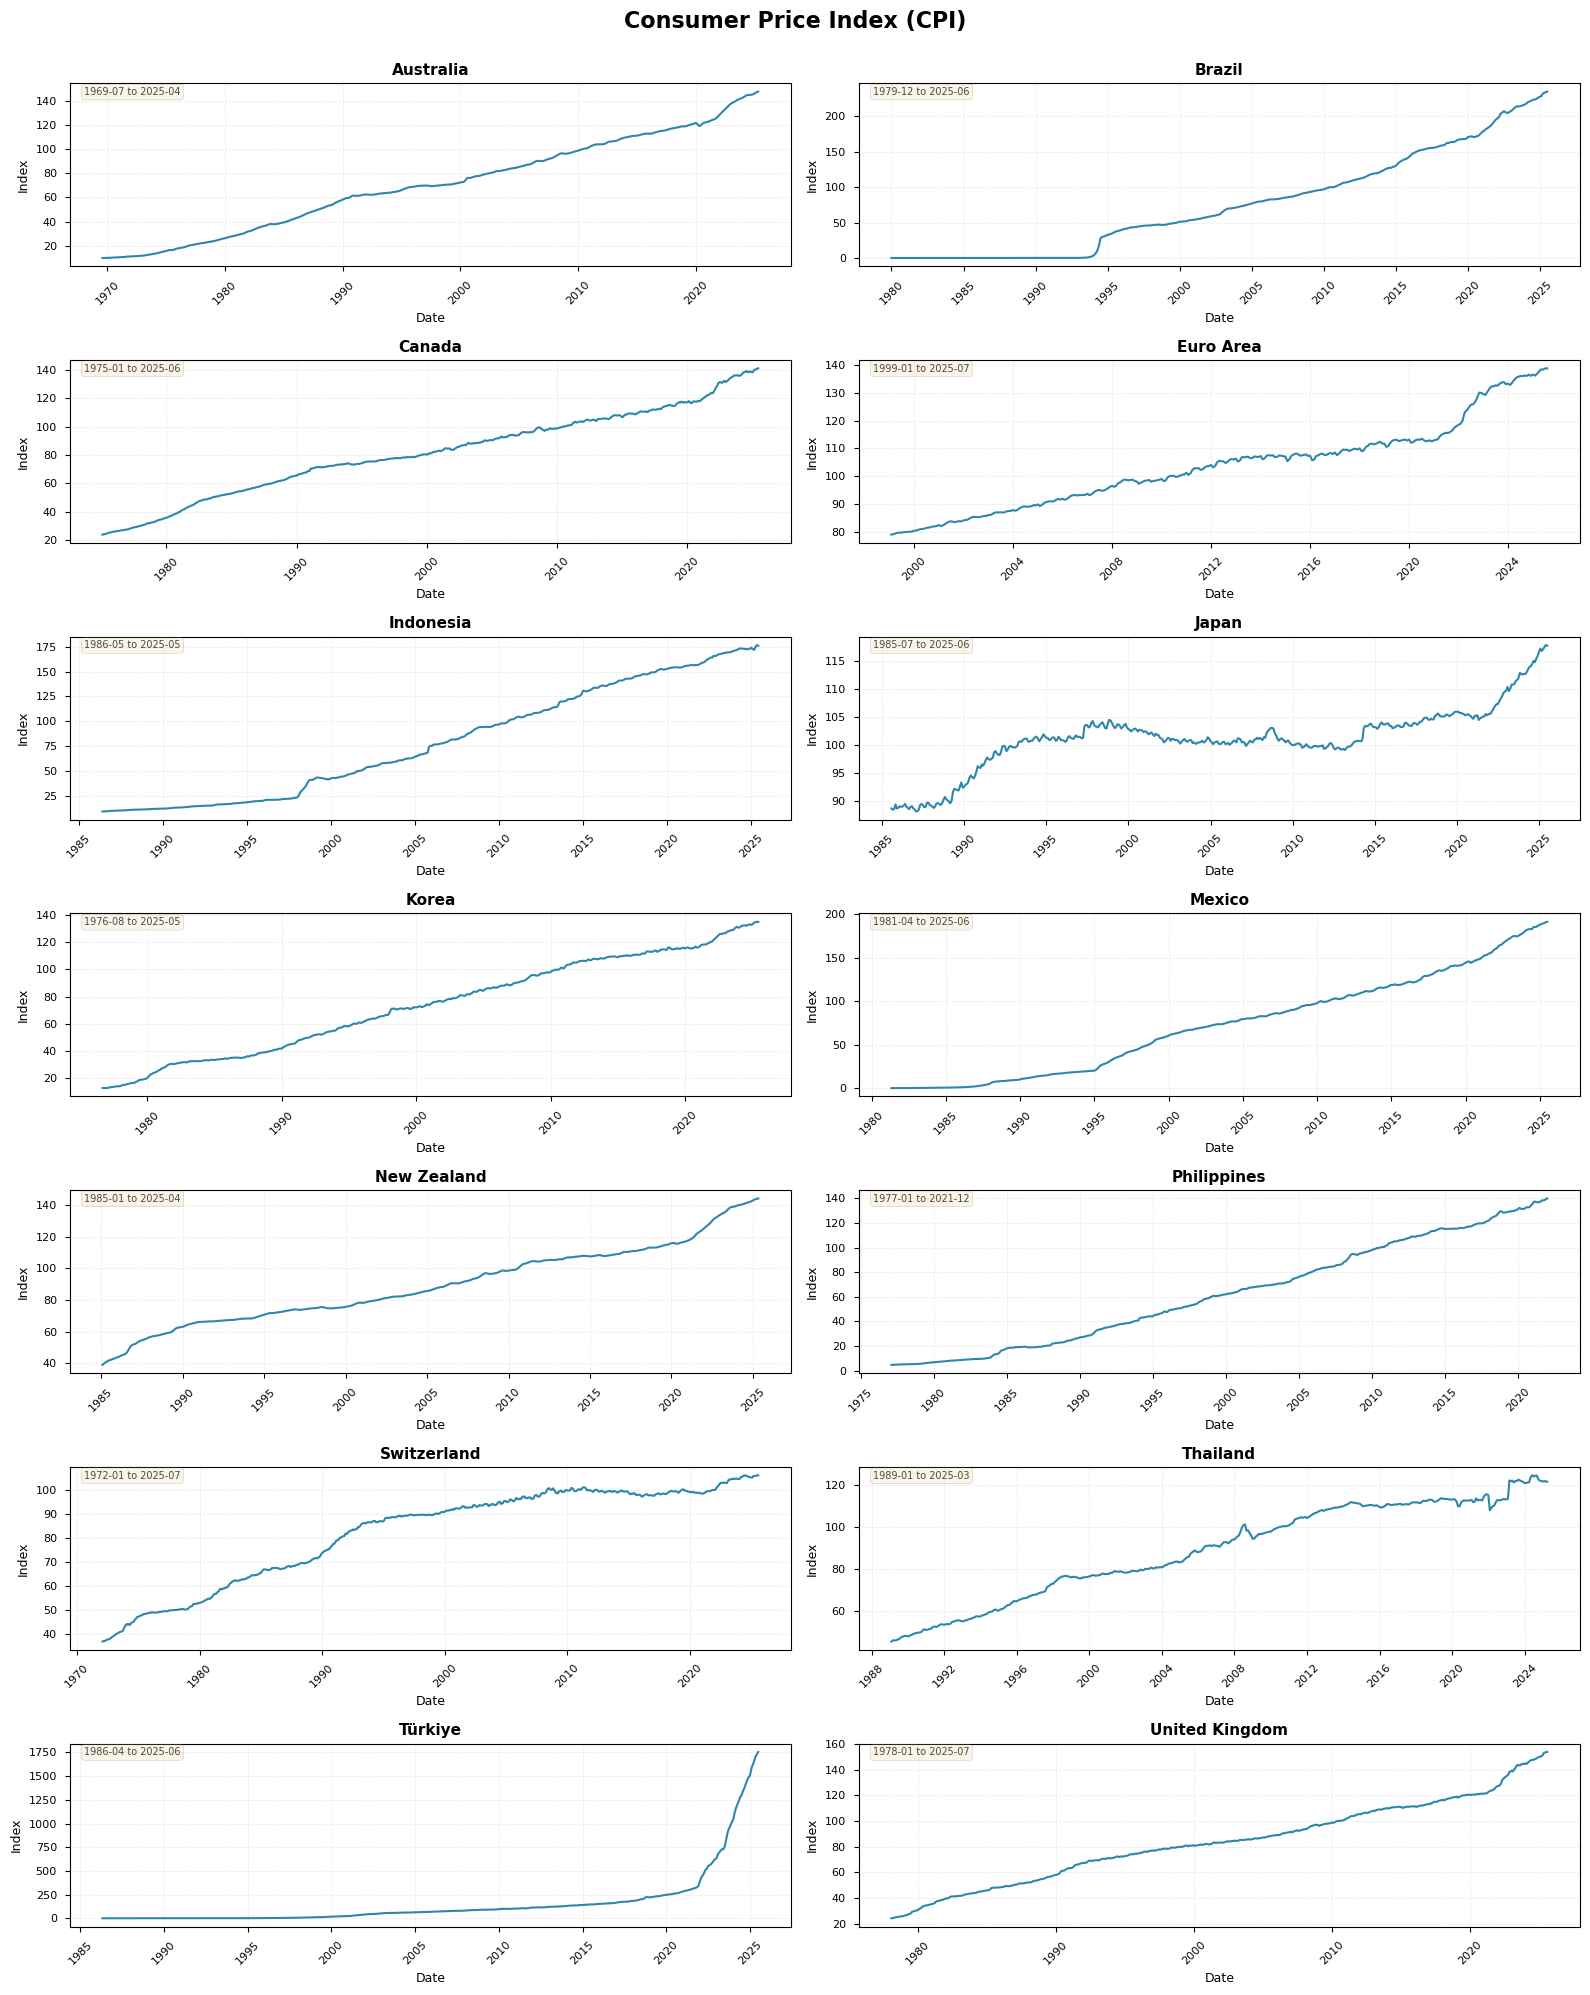

Saved: /Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Python/Plots/exchange_rate_all_countries.png


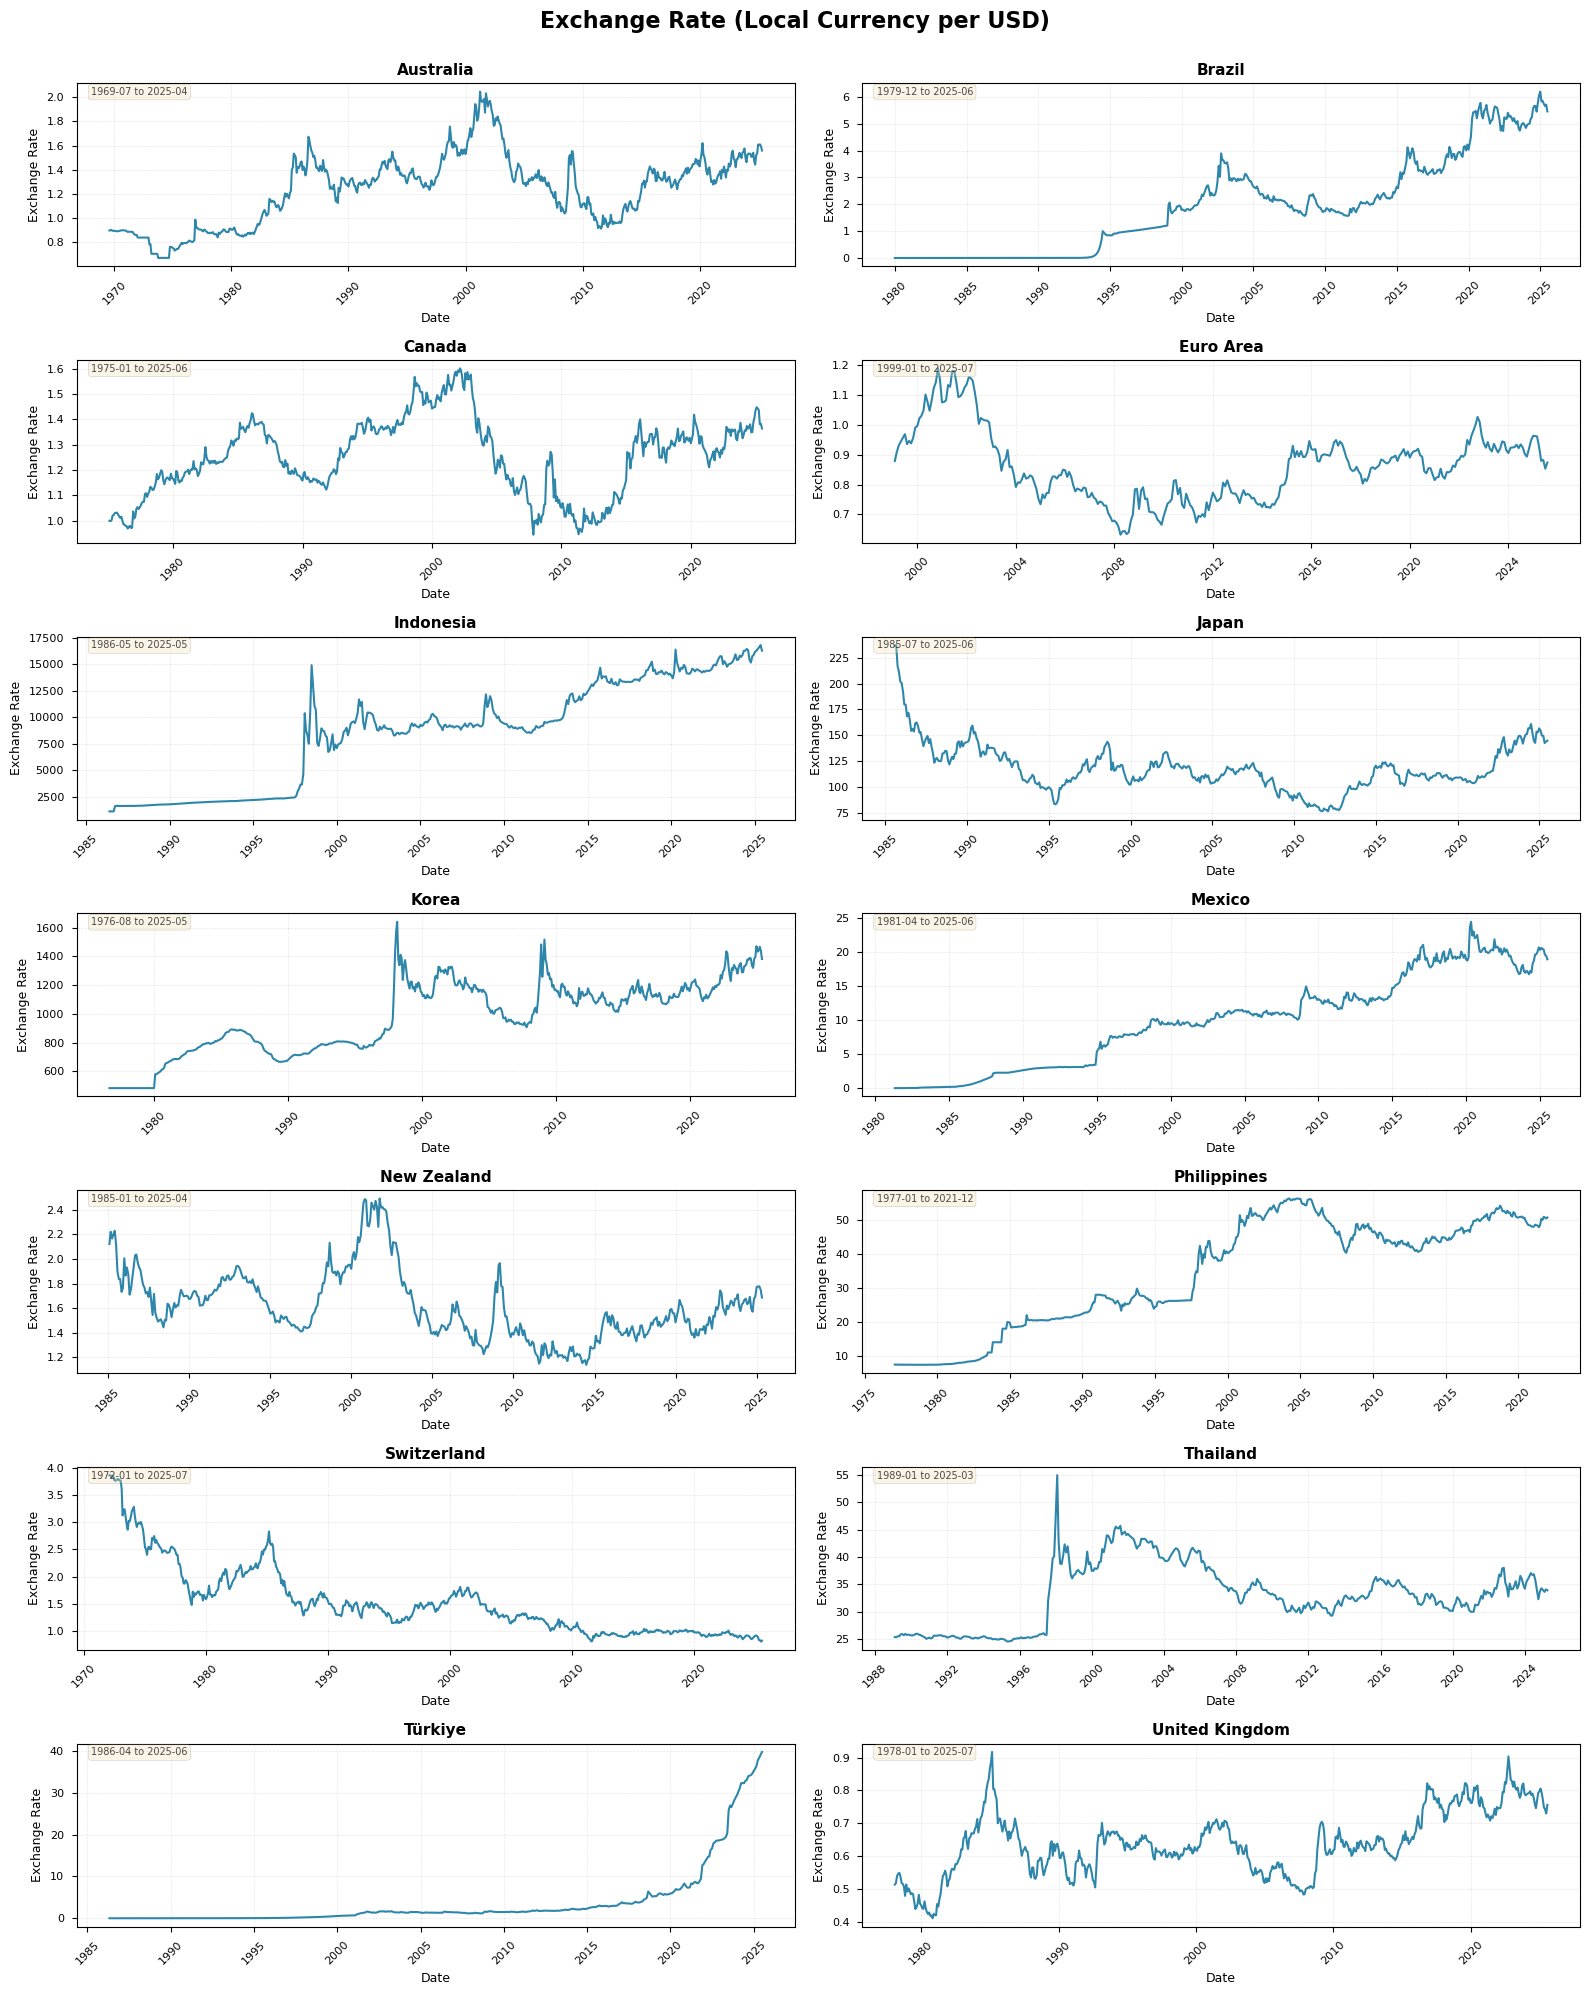

Saved: /Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Python/Plots/policy_rate_all_countries.png


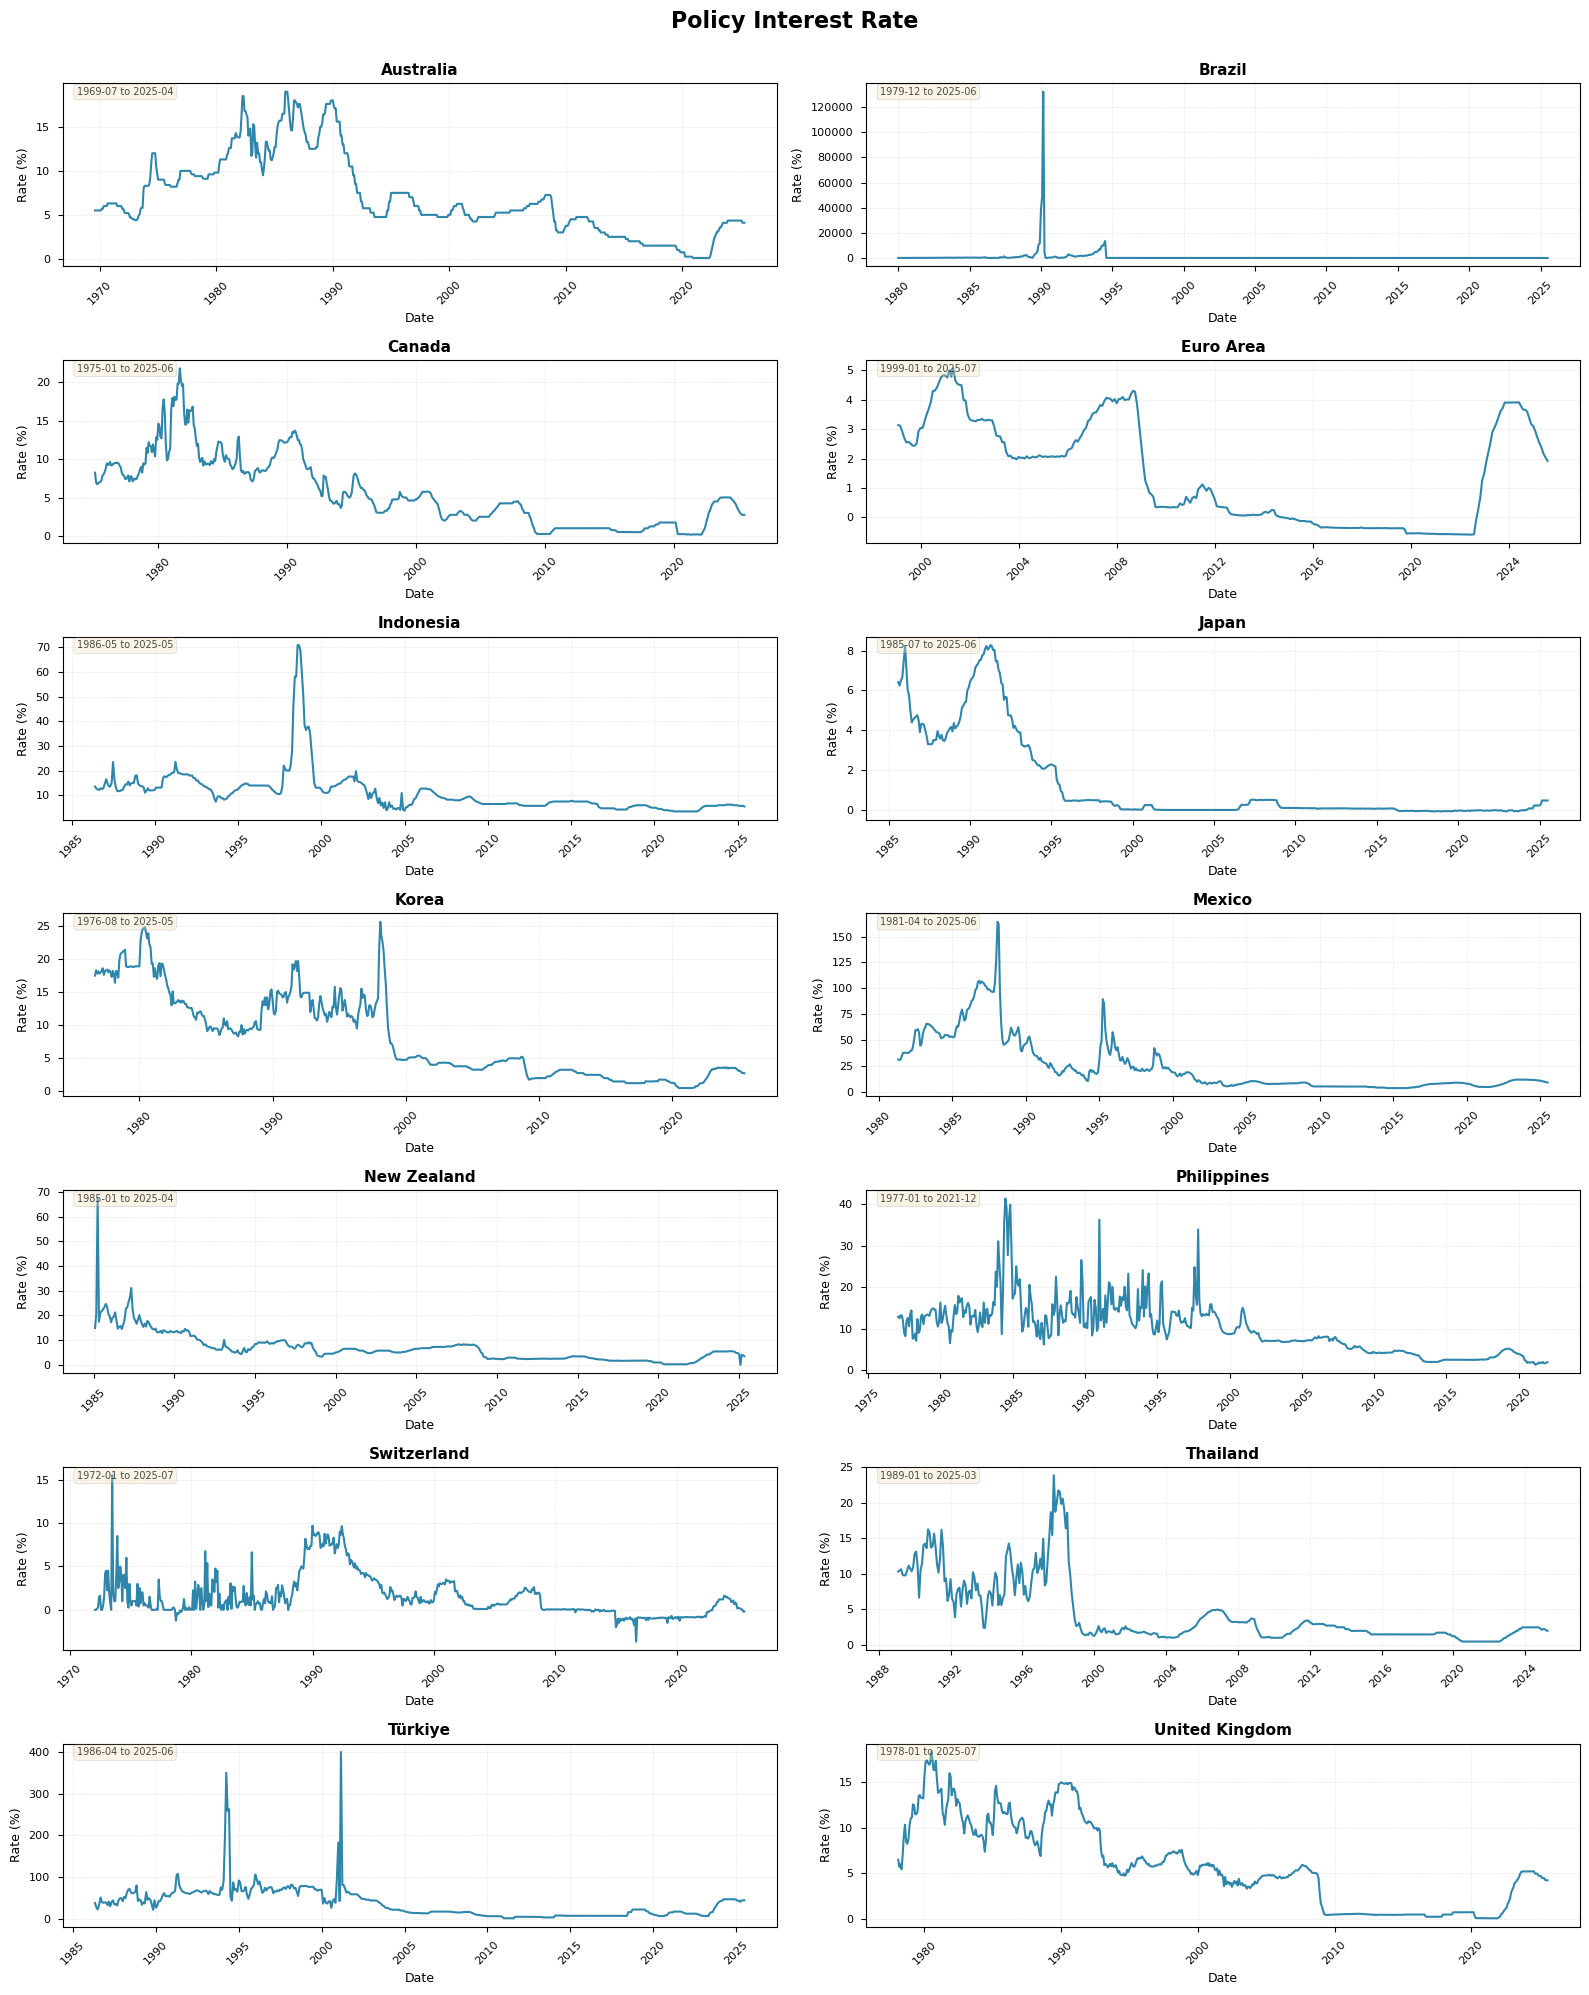

Visualization complete!


In [14]:
from visualize_variables import visualize_variables
visualize_variables(df_filtered, save_plots=True, plot_path="/Users/lollo/Documents/Current_Projects/Master_Thesis2425/BehFXDYN/BFX_Python/Plots")